# Results analysis


Comparison runs, epoch histories, and grid-search results.


In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 100)

OUT = Path("/home/lukas/src/Random Stuff/Predicitve Coding/out")
runs = pd.read_csv(OUT / "results.csv")
run_files = sorted((OUT / "runs").glob("*.json"))
history_rows = []
for path in run_files:
    record = json.loads(path.read_text())
    history = record["history"]
    for epoch, train_metrics, validation_metrics in zip(history["epoch"], history["train"], history["validation"]):
        history_rows.append({
            "model": record["model"], "run_idx": record["run_idx"], "seed": record["seed"], "epoch": epoch,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in validation_metrics.items()},
        })
history = pd.DataFrame(history_rows)
print(f"comparison rows: {len(runs)} rows (trials)")
print(f"run JSON files: {len(run_files)} files (trials)")

comparison rows: 20 rows (trials)
run JSON files: 20 files (trials)


## Comparison data

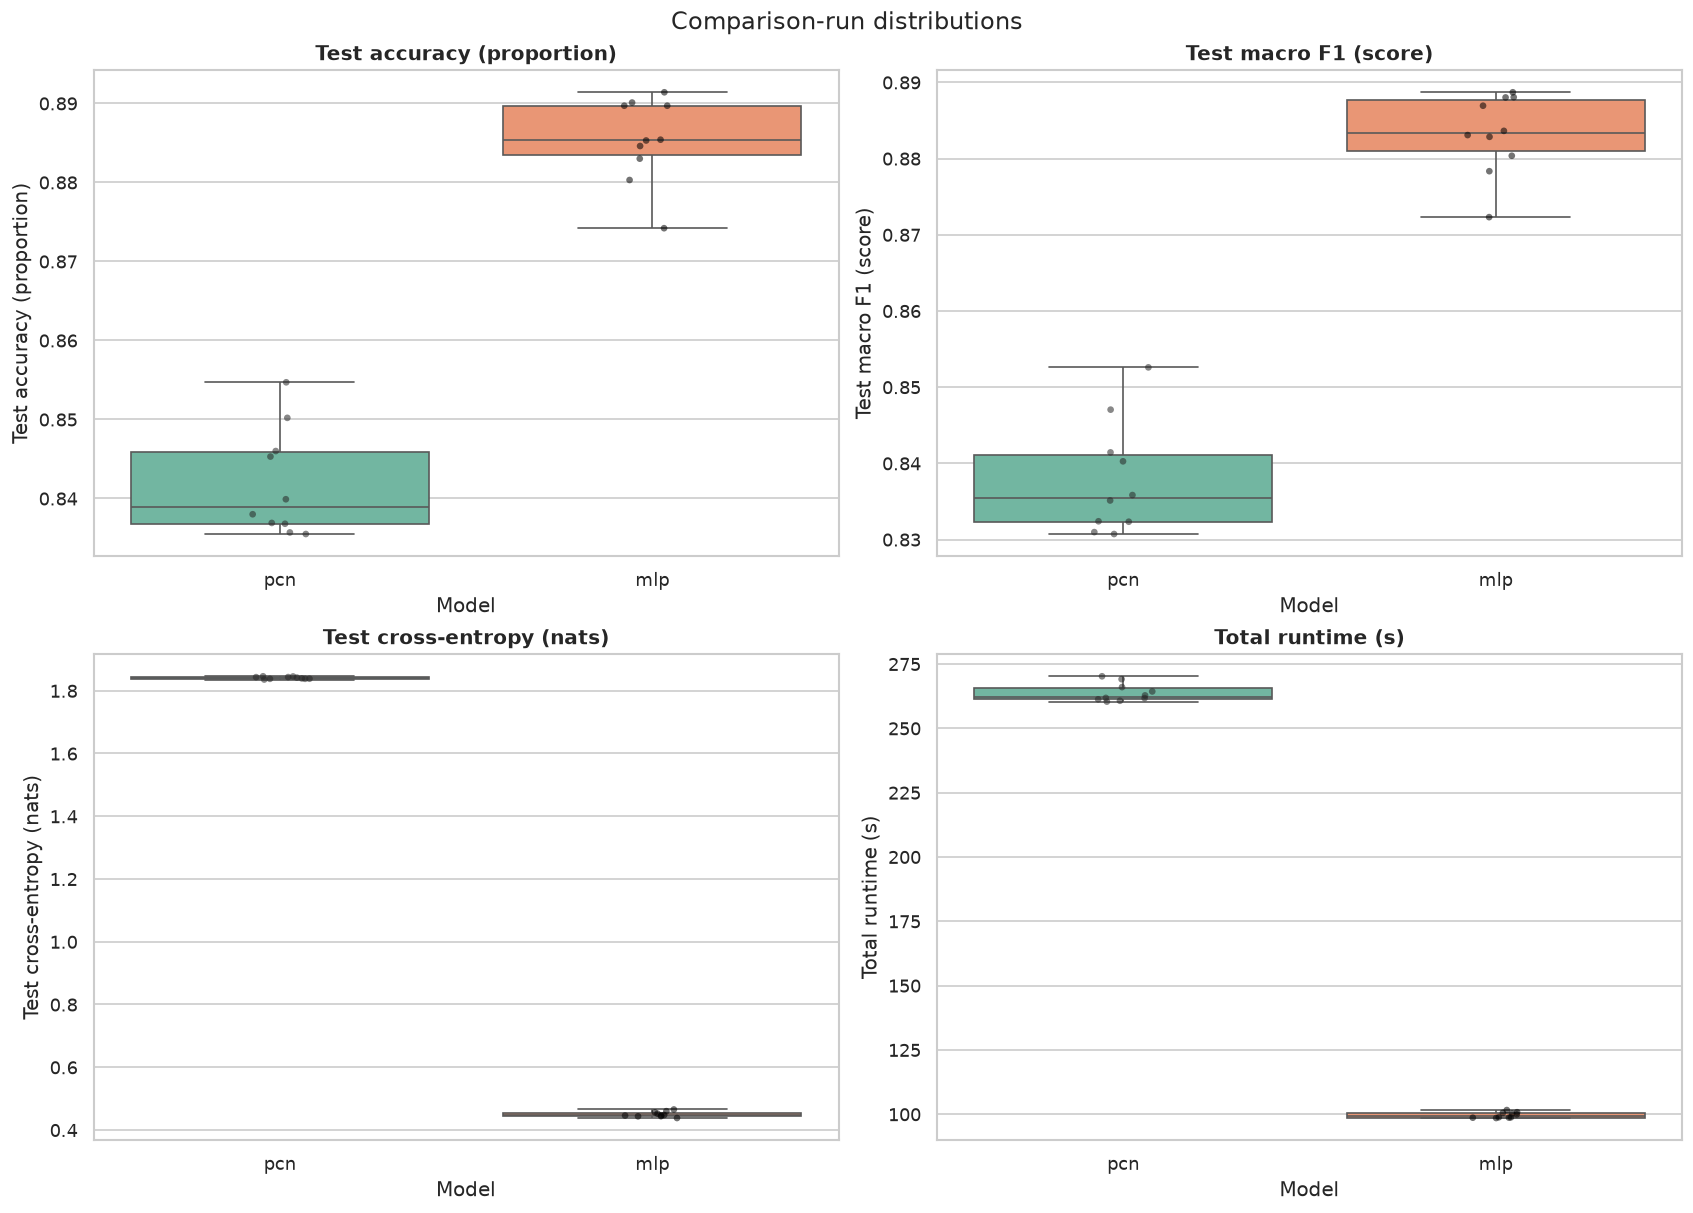

In [15]:
metric_labels = {
    "test_accuracy": "Test accuracy (proportion)",
    "test_f1_macro": "Test macro F1 (score)",
    "test_cross_entropy": "Test cross-entropy (nats)",
    "total_time_s": "Total runtime (s)",
}
long_runs = runs.melt(id_vars=["run_idx", "model", "seed"], value_vars=list(metric_labels), var_name="metric", value_name="value")
long_runs["label"] = long_runs["metric"].map(metric_labels)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, (metric, label) in zip(axes.flat, metric_labels.items()):
    values = long_runs[long_runs.metric == metric]
    sns.boxplot(data=values, x="model", y="value", hue="model", legend=False, ax=ax, palette="Set2")
    sns.stripplot(data=values, x="model", y="value", hue="model", legend=False, ax=ax, palette="dark:black", alpha=.55, jitter=.08, size=4)
    ax.set(title=label, xlabel="Model", ylabel=label)
fig.suptitle("Comparison-run distributions")
plt.show()

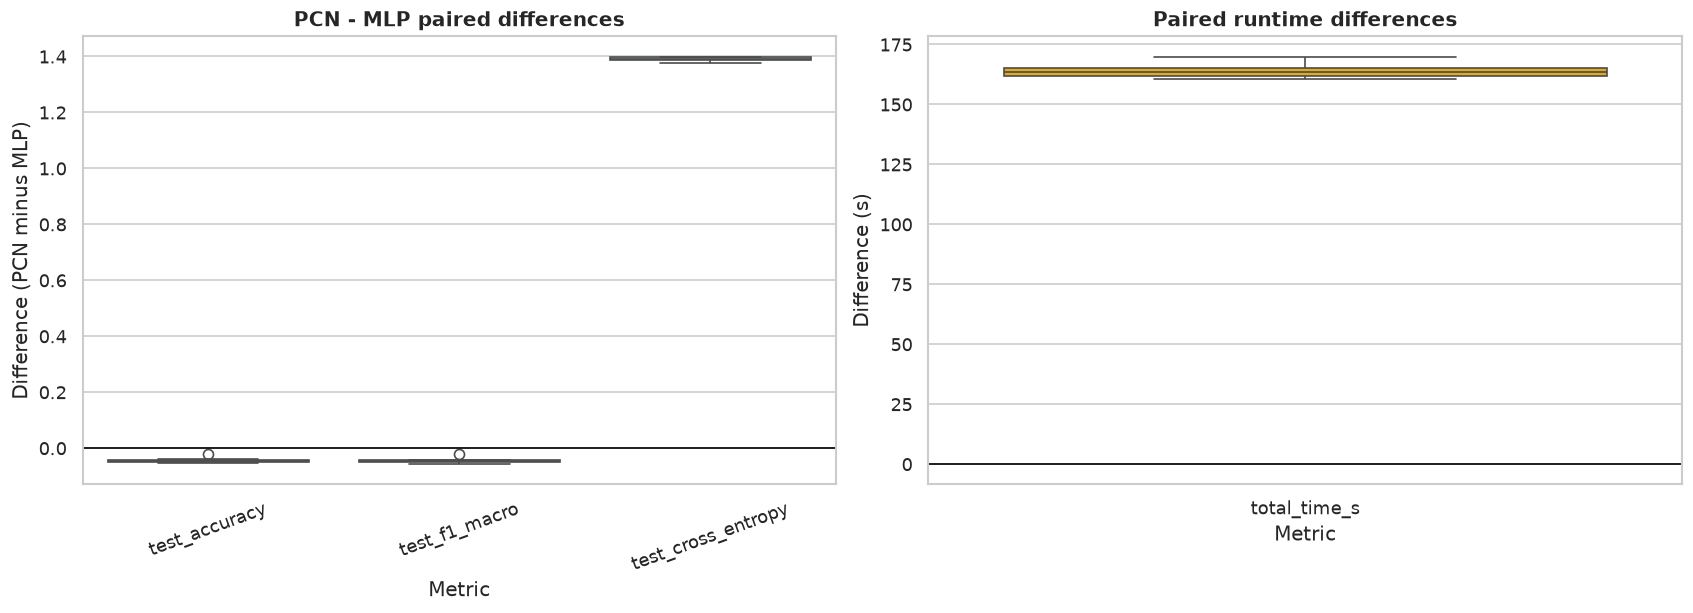

,metric,n paired,mean difference,median difference,mean 95% CI low,mean 95% CI high,median 95% CI low,median 95% CI high,Shapiro-Wilk p,paired t-test p,Wilcoxon p,paired t-test p Holm-adjusted,Wilcoxon p Holm-adjusted
0,Test accuracy (proportion),10,-0.04347,-0.04600,-0.04806,-0.03707,-0.04840,-0.04040,0.01121,0.0,0.00195,0.0,0.00781
1,Test macro F1 (score),10,-0.04536,-0.04750,-0.05026,-0.03859,-0.05075,-0.04251,0.01210,0.0,0.00195,0.0,0.00781
2,Test cross-entropy (nats),10,1.39101,1.39202,1.38635,1.39516,1.38602,1.39758,0.55758,0.0,0.00195,0.0,0.00781
3,Total runtime (s),10,164.17235,163.53716,162.50082,166.07494,161.81619,166.48256,0.26528,0.0,0.00195,0.0,0.00781


In [13]:
paired = runs.pivot(index=["run_idx", "seed"], columns="model", values=list(metric_labels))
paired.columns = [f"{metric}_{model}" for metric, model in paired.columns]
differences = pd.DataFrame({
    metric: paired[f"{metric}_pcn"] - paired[f"{metric}_mlp"]
    for metric in metric_labels
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.boxplot(data=differences.drop(columns="total_time_s"), ax=axes[0], color="#8ecae6")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].set(title="PCN - MLP paired differences", xlabel="Metric", ylabel="Difference (PCN minus MLP)")
sns.boxplot(data=differences[["total_time_s"]], ax=axes[1], color="#ffb703")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Paired runtime differences", xlabel="Metric", ylabel="Difference (s)")
plt.show()


def bootstrap_ci(values, statistic, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, (n_boot, len(values)), replace=True)
    return np.quantile(statistic(samples, axis=1), [.025, .975])


test_rows = []
for metric, label in metric_labels.items():
    values = differences[metric]
    test_rows.append({
        "metric": label,
        "n paired": len(values),
        "mean difference": values.mean(),
        "median difference": values.median(),
        "mean 95% CI low": bootstrap_ci(values, np.mean)[0],
        "mean 95% CI high": bootstrap_ci(values, np.mean)[1],
        "median 95% CI low": bootstrap_ci(values, np.median)[0],
        "median 95% CI high": bootstrap_ci(values, np.median)[1],
        "Shapiro-Wilk p": stats.shapiro(values).pvalue,
        "paired t-test p": stats.ttest_rel(paired[f"{metric}_pcn"], paired[f"{metric}_mlp"]).pvalue,
        "Wilcoxon p": stats.wilcoxon(values).pvalue,
    })
tests = pd.DataFrame(test_rows)
for column in ["paired t-test p", "Wilcoxon p"]:
    tests[column + " Holm-adjusted"] = multipletests(tests[column], method="holm")[1]
tests.round(5)

## Training histories

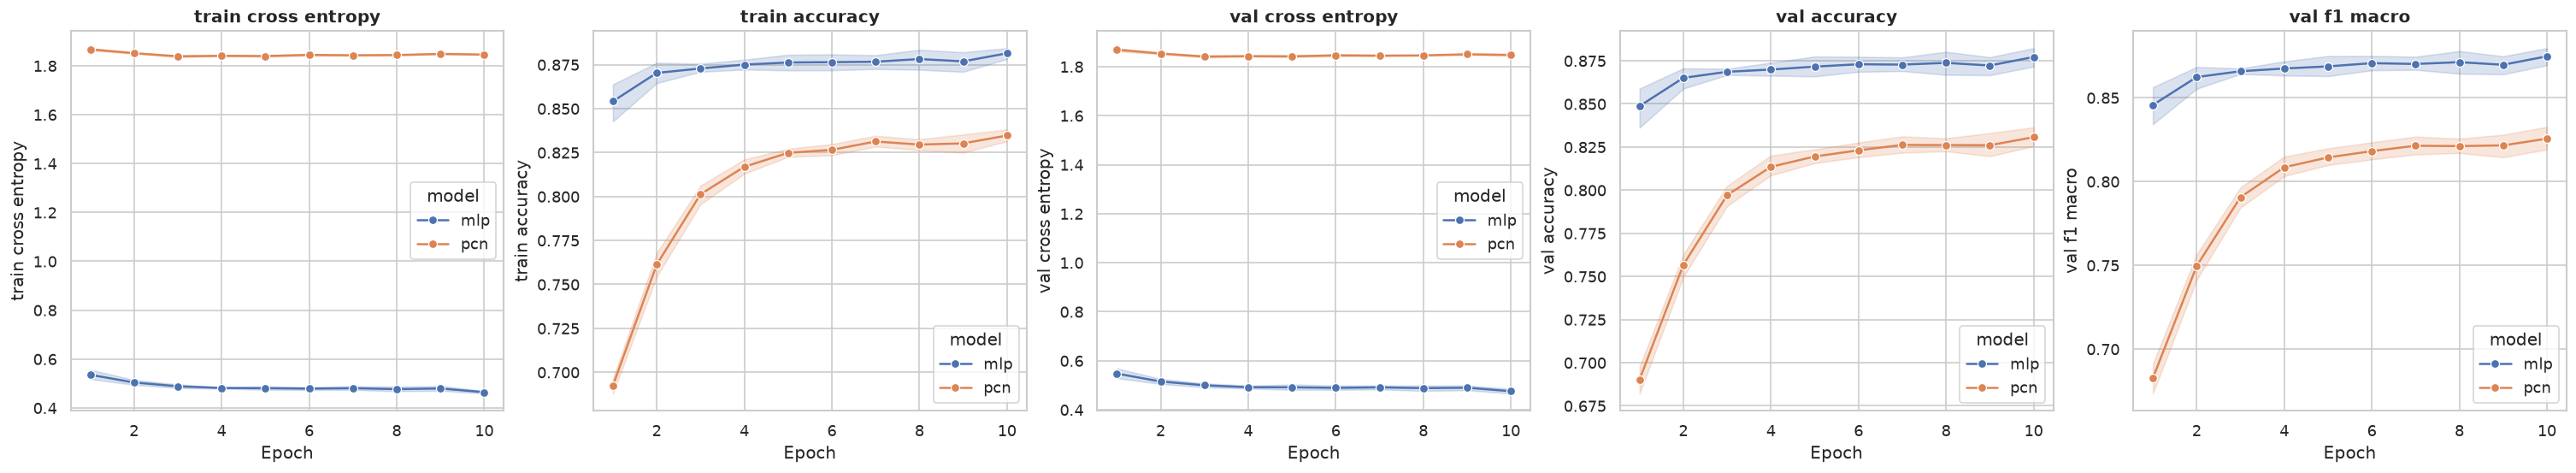

In [14]:
history["epoch"] = pd.to_numeric(history["epoch"])
history_metrics = ["train_cross_entropy", "train_accuracy", "val_cross_entropy", "val_accuracy", "val_f1_macro"]
fig, axes = plt.subplots(1, len(history_metrics), figsize=(5 * len(history_metrics), 4.5), squeeze=False, constrained_layout=True)
for ax, metric in zip(axes[0], history_metrics):
    sns.lineplot(data=history, x="epoch", y=metric, hue="model", errorbar=("ci", 95), marker="o", ax=ax)
    ax.set(title=metric.replace("_", " "), xlabel="Epoch", ylabel=metric.replace("_", " "))
plt.show()